# S4-5 リスク中立評価とニュメレール変換

## 学習目標

- 「なぜ期待値で価格が出るのか」を、複製ポートフォリオと無裁定から自分の言葉で説明できる
- リスク中立測度（risk-neutral measure）と実測度（physical measure）の違いを、割引資産のマルチンゲール性で区別できる
- Girsanov の定理（Girsanov's theorem）を「ドリフトの付け替え」として直感的に理解し、数値で確認できる
- ニュメレール（numéraire）を取り替えると測度が変わることを理解し、フォワード測度・アニュイティ測度への入口を押さえる
- リスクの市場価格（market price of risk）$\theta=(\mu-r)/\sigma$ が測度変換の量であることを説明できる
- 「価格にドリフトは効かないのに、なぜ実務でドリフトを推定するのか」に答えられる

この 1 本は面接で頻出の論点を正面から扱います。数式を追うだけでなく、二項モデルを
手で組み、モンテカルロ（Monte Carlo）で測度変換前後の挙動を数値検証します。

## 実務での位置づけ（ファンドはどう稼ぐか）

リスク中立評価は、デリバティブ評価のすべての土台です。銀行の金利デスクがスワップション・キャップ・エキゾチックを値付けするとき（S5・S6）、価格は「リスク中立測度のもとでの割引後ペイオフの期待値」として計算されます。複製ポートフォリオと無裁定から出発してこの期待値表示にたどり着けることが、なぜモンテカルロやツリーで値段が出るのかの根拠であり、値付けの一貫性（同じキャッシュフローには同じ値段）を担保します。この一貫性が崩れると、自分のブックの中で裁定が生まれ、相手方に取られます。

ニュメレール変換は、金利デリバティブの値付けを実際に回すための道具です。割引債をニュメレールに取ればフォワード測度、年金（アニュイティ）を取ればスワップ測度に移り、そのもとでフォワードレートやスワップレートがマルチンゲールになるので、キャップやスワップションの価格式が扱いやすくなります（S6 への入口）。Girsanov の定理を「ドリフトの付け替え」として数値で確認できることは、この測度の乗り換えを機械的に行える力に直結します。

実測度とリスク中立測度の使い分けは、稼ぎ方の違いそのものです。値付けにドリフトは効かない（リスク中立測度では消える）一方で、ヘッジファンドのマクロやディレクショナルな戦略（S3 のシナリオ、方向観）は実測度のドリフト、すなわち期待リターンを当てにいきます。リスクの市場価格 $\theta=(\mu-r)/\sigma$ がこの二つの測度をつなぐ量で、「価格づけでは消える超過リターンが、アルファの源泉としては生きる」という構図を理解していることが、プライシングデスクと運用サイドの発想の切り替えになります。面接で頻出の論点であり、両者を混同しないことは実務でも評価の分かれ目です。


## 理論

### 1. 複製ポートフォリオと無裁定

価格づけの出発点は「同じ将来キャッシュフローを生む二つの持ち高は、今日同じ値段でなければ
ならない」という**無裁定（no-arbitrage）**の原則です。もし値段が違えば、安い方を買い高い方を
売れば無リスクで儲かってしまうからです。

あるデリバティブのペイオフを、原資産と無リスク債の組み合わせで**複製（replicate）**できたと
します。すると無裁定から、デリバティブの価格は複製ポートフォリオの組成コストに一致します。
これが「期待値で価格が出る」ことの本当の根拠です。期待値の計算は、複製コストを別の形で
書き直したものにすぎません。

### 2. 1 期間二項モデルでの複製

1 期間・二項の世界を考えます。今日の株価 $S_0$ が、期末に上昇 $S_0 u$ か下落 $S_0 d$（$d<1+r<u$）の
どちらかになります。$r$ は 1 期間の無リスク金利です。デリバティブのペイオフを、上昇時 $f_u$・
下落時 $f_d$ とします。

株を $\Delta$ 単位、無リスク債（現金）を $B$ だけ持つポートフォリオでこのペイオフを複製します。

$$
\Delta S_0 u + B(1+r) = f_u, \qquad \Delta S_0 d + B(1+r) = f_d .
$$

連立を解くと

$$
\Delta = \frac{f_u - f_d}{S_0(u-d)}, \qquad
B = \frac{u f_d - d f_u}{(1+r)(u-d)} .
$$

今日の複製コストがデリバティブ価格です。

$$
f_0 = \Delta S_0 + B = \frac{1}{1+r}\Big[q f_u + (1-q) f_d\Big], \qquad
q = \frac{(1+r)-d}{u-d} .
$$

ここで現れた $q$ が**リスク中立確率（risk-neutral probability）**です。実際の上昇確率 $p$ は
一切式に出てきません。価格は「複製コスト」であって「現実の当たりやすさ」ではないからです。

### 3. リスク中立測度と実測度

$q$ は $\displaystyle \frac{1}{1+r}\big[q\,S_0 u+(1-q)S_0 d\big]=S_0$ を満たすように決まっています。
つまり $q$ の下では**割引株価がマルチンゲール（martingale）**になります。

$$
S_0 = \mathbb{E}^{\mathbb{Q}}\!\left[\frac{S_1}{1+r}\right].
$$

この $\mathbb{Q}$ を**リスク中立測度**と呼びます。対して、現実の値動き（上昇確率 $p$、期待リターン
$\mu$）を記述するのが**実測度 $\mathbb{P}$** です。両者は「起こりうる事象の集合」は共有しますが、
各事象に割り当てる確率が違います。価格づけは $\mathbb{Q}$、リスク管理やシナリオ分析は $\mathbb{P}$ を使います。

### 4. 連続時間と Girsanov の定理

連続時間では、原資産を幾何ブラウン運動（geometric Brownian motion）で書きます。実測度 $\mathbb{P}$ の下で

$$
dS_t = \mu S_t\, dt + \sigma S_t\, dW_t^{\mathbb{P}} .
$$

**Girsanov の定理**は、測度を $\mathbb{P}$ から $\mathbb{Q}$ へ取り替えると、ブラウン運動にドリフトが
付け替わることを述べます。

$$
W_t^{\mathbb{Q}} = W_t^{\mathbb{P}} + \theta\, t, \qquad \theta=\frac{\mu-r}{\sigma}.
$$

これを代入すると、$\mathbb{Q}$ の下でドリフトが $\mu$ から $r$ へ置き換わります。

$$
dS_t = r S_t\, dt + \sigma S_t\, dW_t^{\mathbb{Q}} .
$$

拡散項 $\sigma$ は不変で、変わるのはドリフトだけです。これが「ドリフトの付け替え」という直感です。
測度変換の重みは**ラドン・ニコディム微分（Radon–Nikodym derivative）**

$$
\frac{d\mathbb{Q}}{d\mathbb{P}} = \exp\!\Big(-\theta W_T^{\mathbb{P}} - \tfrac12 \theta^2 T\Big)
$$

で与えられ、$\theta$ が付け替え量を測ります。

### 5. リスクの市場価格

$\theta=(\mu-r)/\sigma$ を**リスクの市場価格**と呼びます。分子 $\mu-r$ は超過リターン、分母 $\sigma$ は
引き受けるリスク量で、「リスク 1 単位あたりの超過リターン」を表します。Girsanov の付け替え量が
ちょうどこの $\theta$ であることが、リスク中立化の本質です。$\mathbb{Q}$ の下では全ての資産が
「リスクプレミアムを剥がした」金利 $r$ で成長します。

### 6. ニュメレール変換

ここまでは無リスク債（マネーマーケット口座 $M_t=e^{rt}$）を価値の基準＝**ニュメレール**に選び、
それで割った価格をマルチンゲールにしました。実は基準に選ぶ資産は無リスク債でなくてもよく、
正の価格を持つ資産ならどれでもニュメレールにできます。ニュメレールを $N_t$ に取り替えると、
それに応じた測度 $\mathbb{Q}^N$ が対応し、任意の資産価格 $V_t$ について $V_t/N_t$ がマルチンゲールになります。

$$
\frac{V_t}{N_t} = \mathbb{E}^{\mathbb{Q}^N}\!\left[\frac{V_T}{N_T}\,\middle|\,\mathcal{F}_t\right].
$$

金利デリバティブでは、この取り替えが計算を劇的に簡単にします。

| ニュメレール | 対応する測度 | 主な用途 |
|---|---|---|
| マネーマーケット口座 $e^{rt}$ | リスク中立測度 $\mathbb{Q}$ | 一般の評価の出発点 |
| 割引債 $P(t,T)$ | $T$-フォワード測度 $\mathbb{Q}^T$ | カプレット・先渡し（S6） |
| アニュイティ $\sum \tau_i P(t,T_i)$ | アニュイティ測度 $\mathbb{Q}^A$ | スワップション（S6） |

本 notebook では入口として、無リスク債ニュメレールでの $\mathbb{Q}$ を数値で確認します。
フォワード測度・アニュイティ測度の実装は S6 で扱います。

**数値例**（リスクの市場価格）：$\mu=0.12$、$r=0.03$、$\sigma=0.2$ のとき $\theta=\dfrac{\mu-r}{\sigma}=\dfrac{0.09}{0.2}=0.45$ です。これが Girsanov でのドリフト付け替え量で、$\mathbb{Q}$ の下ではブラウン運動が $W_t^{\mathbb{Q}}=W_t^{\mathbb{P}}+0.45\,t$ とシフトします。

**数値例**（リスク中立確率と価格）：$S_0=100$、$u=1.2$、$d=0.9$、$r=2\%$ のとき $q=\dfrac{(1+r)-d}{u-d}=\dfrac{1.02-0.9}{0.3}=0.4$ です。$K=105$ のコール（$f_u=15,\ f_d=0$）なら価格は $\dfrac{q f_u+(1-q)f_d}{1+r}=\dfrac{0.4\cdot15}{1.02}\approx5.88$ となります。

## スクラッチ実装

ここからは理論を手で確かめます。まず 1 期間二項モデルで複製を組み、リスク中立確率を
自分で計算します。次に多期間へ拡張し、最後に `bondlab.sim.brownian_paths` で
ドリフトの付け替えを可視化します。

### 使用する自作関数

二項モデルと Black–Scholes は本 notebook で自作します（QuantLib は後段の検証役）。

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `replicate_one_period(S0, u, d, r, f_u, f_d)` | 現在株価, 上昇率, 下落率, 期間金利, 上昇/下落ペイオフ | dict（delta, bond, price, q） | 1 期間複製とリスク中立確率 |
| `crr_params(sigma, dt)` | ボラティリティ, 刻み幅 | (u, d) | CRR の上昇率・下落率 |
| `binomial_price(S0, K, r, sigma, T, n, kind)` | 株価, 行使価格, 金利, ボラ, 満期, ステップ数, 種別 | 価格 | CRR 二項モデル価格 |
| `bs_price(S0, K, r, sigma, T, kind)` | 同上（連続極限） | 価格 | Black–Scholes 解析解 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
from scipy.stats import norm

import bondlab
from bondlab.sim import brownian_paths

print("bondlab version:", bondlab.__version__)

np.random.seed(0)  # notebook 全体の再現性（brownian_paths には seed 引数を別途渡す）


def replicate_one_period(S0, u, d, r, f_u, f_d):
    """1 期間二項モデルでデリバティブを複製し、価格とリスク中立確率を返す。

    株 delta 単位 + 現金 bond で (f_u, f_d) を複製する。無裁定より
    複製コスト = デリバティブ価格。q は割引株価をマルチンゲールにする確率。
    """
    delta = (f_u - f_d) / (S0 * (u - d))
    bond = (u * f_d - d * f_u) / ((1 + r) * (u - d))
    price = delta * S0 + bond
    q = ((1 + r) - d) / (u - d)
    return dict(delta=delta, bond=bond, price=price, q=q)


def crr_params(sigma, dt):
    """Cox–Ross–Rubinstein の上昇率 u・下落率 d（u*d=1 の対称格子）。"""
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    return u, d


def binomial_price(S0, K, r_cont, sigma, T, n, kind="call"):
    """CRR n ステップ二項モデルのヨーロピアン・オプション価格。

    r_cont は連続複利金利。各ステップの割引は exp(-r_cont*dt)、
    リスク中立確率 q は (exp(r_cont*dt)-d)/(u-d)。満期ペイオフを
    q で重み付けしながら後ろ向きに割り引く。
    """
    dt = T / n
    u, d = crr_params(sigma, dt)
    disc = np.exp(-r_cont * dt)
    q = (np.exp(r_cont * dt) - d) / (u - d)
    # 満期の株価とペイオフ（上昇 j 回・下落 n-j 回）
    j = np.arange(n + 1)
    ST = S0 * u ** j * d ** (n - j)
    if kind == "call":
        values = np.maximum(ST - K, 0.0)
    else:
        values = np.maximum(K - ST, 0.0)
    # 後ろ向き帰納：各ノードで q 期待値を割り引く
    for _ in range(n):
        values = disc * (q * values[1:] + (1 - q) * values[:-1])
    return float(values[0])


def bs_price(S0, K, r_cont, sigma, T, kind="call"):
    """Black–Scholes 解析解（連続複利金利 r_cont）。"""
    d1 = (np.log(S0 / K) + (r_cont + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return float(S0 * norm.cdf(d1) - K * np.exp(-r_cont * T) * norm.cdf(d2))
    else:
        return float(K * np.exp(-r_cont * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1))

bondlab version: 0.0.1


### 1 期間モデルで複製とリスク中立確率を確かめる

具体的な数値で複製ポートフォリオを組みます。$S_0=100$、上昇 $u=1.2$、下落 $d=0.9$、
1 期間金利 $r=2\%$。行使価格 $K=105$ のコールを複製します。

In [2]:
S0, u, d, r = 100.0, 1.2, 0.9, 0.02
K = 105.0
f_u = max(S0 * u - K, 0.0)   # 上昇時ペイオフ = max(120-105,0)=15
f_d = max(S0 * d - K, 0.0)   # 下落時ペイオフ = max(90-105,0)=0

rep = replicate_one_period(S0, u, d, r, f_u, f_d)
print(f"複製に必要な株数 delta      = {rep['delta']:.6f}")
print(f"複製に必要な現金 bond       = {rep['bond']:.6f}")
print(f"複製コスト = オプション価格 = {rep['price']:.6f}")
print(f"リスク中立確率 q            = {rep['q']:.6f}")

# 価格をリスク中立期待値としても計算し、一致を確認する。
q = rep["q"]
price_expectation = (q * f_u + (1 - q) * f_d) / (1 + r)
print(f"リスク中立期待値による価格  = {price_expectation:.6f}")
assert abs(rep["price"] - price_expectation) < 1e-12
print("→ 複製コストとリスク中立期待値が一致しました")

複製に必要な株数 delta      = 0.500000
複製に必要な現金 bond       = -44.117647
複製コスト = オプション価格 = 5.882353
リスク中立確率 q            = 0.400000
リスク中立期待値による価格  = 5.882353
→ 複製コストとリスク中立期待値が一致しました


実際の上昇確率 $p$ をいくら動かしても、複製コスト（＝価格）は変わりません。
$p$ は価格の式に登場しないからです。これを数値で見せます。

In [3]:
for p in [0.3, 0.5, 0.7, 0.9]:
    # 実測度での期待ペイオフ（割引）は p に依存するが、これは「価格」ではない
    naive = (p * f_u + (1 - p) * f_d) / (1 + r)
    print(f"実確率 p={p:.1f}: 素朴な実測度期待値={naive:6.3f} / 無裁定価格={rep['price']:.3f}")
print("→ 実確率 p を変えても無裁定価格は不変（価格は複製コストで決まる）")

実確率 p=0.3: 素朴な実測度期待値= 4.412 / 無裁定価格=5.882
実確率 p=0.5: 素朴な実測度期待値= 7.353 / 無裁定価格=5.882
実確率 p=0.7: 素朴な実測度期待値=10.294 / 無裁定価格=5.882
実確率 p=0.9: 素朴な実測度期待値=13.235 / 無裁定価格=5.882
→ 実確率 p を変えても無裁定価格は不変（価格は複製コストで決まる）


### 多期間二項モデル

1 期間の複製を各ノードで積み重ねると多期間モデルになります。後ろ向き帰納で価格が出ます。
パラメータは連続複利金利 $r=3\%$、ボラティリティ $\sigma=20\%$、満期 $T=1$ 年、$S_0=100$、$K=100$。

In [4]:
S0, K, r_cont, sigma, T = 100.0, 100.0, 0.03, 0.20, 1.0
for n in [1, 2, 5, 10, 50]:
    price = binomial_price(S0, K, r_cont, sigma, T, n, kind="call")
    print(f"n={n:3d} ステップ二項価格 = {price:.6f}")

n=  1 ステップ二項価格 = 11.297241
n=  2 ステップ二項価格 = 8.510819
n=  5 ステップ二項価格 = 9.796472
n= 10 ステップ二項価格 = 9.217851
n= 50 ステップ二項価格 = 9.373839


### ドリフトの付け替えを可視化する

`bondlab.sim.brownian_paths` で同一のブラウン運動 $W$ を生成し、それを実測度 $\mathbb{P}$
（ドリフト $\mu$）とリスク中立測度 $\mathbb{Q}$（ドリフト $r$）の両方で解釈します。増分 $dW$ は
共通で、変わるのはドリフトだけ、という Girsanov の直感を目で見ます。

$$
S_t^{\mathbb{P}} = S_0 e^{(\mu-\sigma^2/2)t + \sigma W_t}, \qquad
S_t^{\mathbb{Q}} = S_0 e^{(r-\sigma^2/2)t + \sigma W_t}.
$$

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


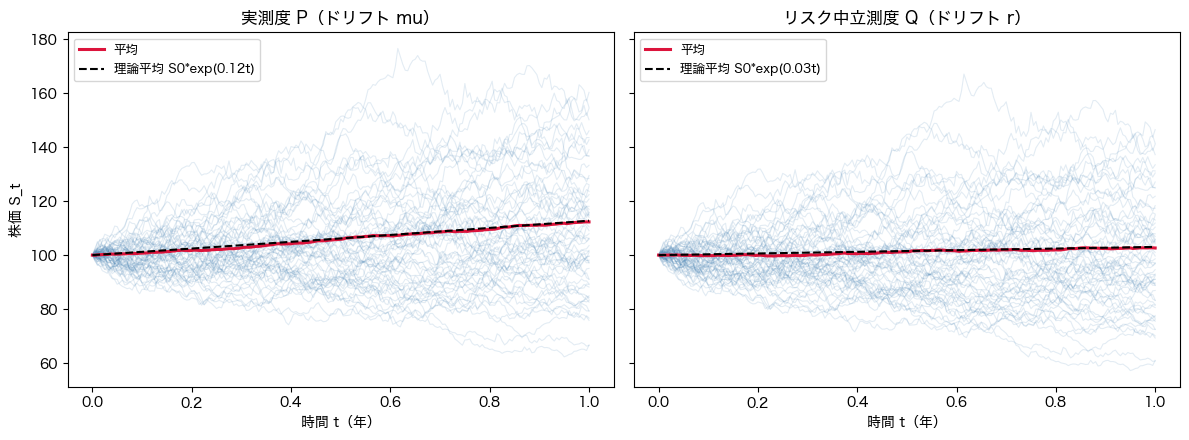

P の期末平均株価  = 112.314（理論 112.750）
Q の期末平均株価  = 102.647（理論 103.045）


In [5]:
mu = 0.12          # 実測度の期待リターン（r より高い）
n_paths, n_steps = 400, 200
times, W = brownian_paths(n_paths, n_steps, T, seed=42)

S_P = S0 * np.exp((mu - 0.5 * sigma ** 2) * times + sigma * W)
S_Q = S0 * np.exp((r_cont - 0.5 * sigma ** 2) * times + sigma * W)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, S, title, drift in (
    (axes[0], S_P, "実測度 P（ドリフト mu）", mu),
    (axes[1], S_Q, "リスク中立測度 Q（ドリフト r）", r_cont),
):
    ax.plot(times, S[:60].T, color="steelblue", alpha=0.15, lw=0.8)
    ax.plot(times, S.mean(axis=0), color="crimson", lw=2.2, label="平均")
    ax.plot(times, S0 * np.exp(drift * times), color="black", lw=1.5, ls="--",
            label=f"理論平均 S0*exp({drift:.2f}t)")
    ax.set_title(title)
    ax.set_xlabel("時間 t（年）")
    ax.legend(loc="upper left", fontsize=9)
axes[0].set_ylabel("株価 S_t")
plt.tight_layout()
plt.show()

print(f"P の期末平均株価  = {S_P[:, -1].mean():.3f}（理論 {S0*np.exp(mu*T):.3f}）")
print(f"Q の期末平均株価  = {S_Q[:, -1].mean():.3f}（理論 {S0*np.exp(r_cont*T):.3f}）")

同じ増分でも、雲の中心（平均）の傾きが $\mu$ から $r$ へ付け替わっているのが分かります。
拡散の広がり方（雲の幅）は両者で同一です。

### 割引資産のマルチンゲール性を数値検証する

リスク中立測度 $\mathbb{Q}$ の下では、割引株価 $e^{-rt}S_t$ が全ての $t$ で平均 $S_0$ に
保たれる（マルチンゲール）はずです。実測度 $\mathbb{P}$ の下ではドリフトが残るので保たれません。

In [6]:
disc = np.exp(-r_cont * times)
disc_S_Q = disc * S_Q
disc_S_P = disc * S_P

print(f"{'t':>6} {'E[e^-rt S_t] (Q)':>18} {'E[e^-rt S_t] (P)':>18}")
for i in [0, n_steps // 4, n_steps // 2, 3 * n_steps // 4, n_steps]:
    print(f"{times[i]:6.2f} {disc_S_Q[:, i].mean():18.4f} {disc_S_P[:, i].mean():18.4f}")

# Q の割引株価は S0 付近で平坦（マルチンゲール）
assert abs(disc_S_Q[:, -1].mean() - S0) / S0 < 0.02
print(f"\n→ Q では割引株価の期末平均 {disc_S_Q[:, -1].mean():.3f} ≈ S0={S0}（マルチンゲール）")
print(f"→ P では割引株価の期末平均 {disc_S_P[:, -1].mean():.3f} ≈ S0*exp((mu-r)T)="
      f"{S0*np.exp((mu-r_cont)*T):.3f}（ドリフトが残る）")

     t   E[e^-rt S_t] (Q)   E[e^-rt S_t] (P)
  0.00           100.0000           100.0000
  0.25            99.0851           101.3398
  0.50            99.7105           104.2999
  0.75            99.4629           106.4084
  1.00            99.6132           108.9942

→ Q では割引株価の期末平均 99.613 ≈ S0=100.0（マルチンゲール）
→ P では割引株価の期末平均 108.994 ≈ S0*exp((mu-r)T)=109.417（ドリフトが残る）


## QuantLib 検証

この節の**検証の位置づけ**を明記します。本 notebook では二項モデルと Black–Scholes を
自作しました。したがって QuantLib での答え合わせは、次の二点を確かめることに充てます。

1. **二項モデルの Black–Scholes 極限への収束**：ステップ数 $n\to\infty$ で二項価格が連続時間の
   解析解へ収束することを確認します。
2. **複製コスト = リスク中立期待値の一致**：モンテカルロによる $\mathbb{Q}$ 期待値が、複製から出た
   解析解価格へ一致することを確認します。

あわせて QuantLib の解析エンジン・二項エンジンを独立なベンチマークとして突き合わせます。

### 検証 1：二項モデルの BS 極限への収束

In [7]:
bs_ref = bs_price(S0, K, r_cont, sigma, T, kind="call")
print(f"Black–Scholes 解析解 = {bs_ref:.6f}\n")
print(f"{'n':>6} {'二項価格':>12} {'BSとの差':>14}")
ns = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
errs = []
for n in ns:
    bp = binomial_price(S0, K, r_cont, sigma, T, n, kind="call")
    err = bp - bs_ref
    errs.append(abs(err))
    print(f"{n:6d} {bp:12.6f} {err:14.6e}")

assert errs[-1] < 1e-2
print(f"\n→ n=1024 で差 {errs[-1]:.2e}。ステップ数を増やすと BS 解へ収束します")

Black–Scholes 解析解 = 9.413403

     n         二項価格          BSとの差
     1    11.297241   1.883838e+00
     2     8.510819  -9.025848e-01
     4     8.937298  -4.761057e-01
     8     9.169940  -2.434635e-01
    16     9.290490  -1.229131e-01
    32     9.351677  -6.172627e-02
    64     9.382476  -3.092715e-02
   128     9.397924  -1.547914e-02
   256     9.405660  -7.743408e-03
   512     9.409531  -3.872656e-03
  1024     9.411467  -1.936565e-03

→ n=1024 で差 1.94e-03。ステップ数を増やすと BS 解へ収束します


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


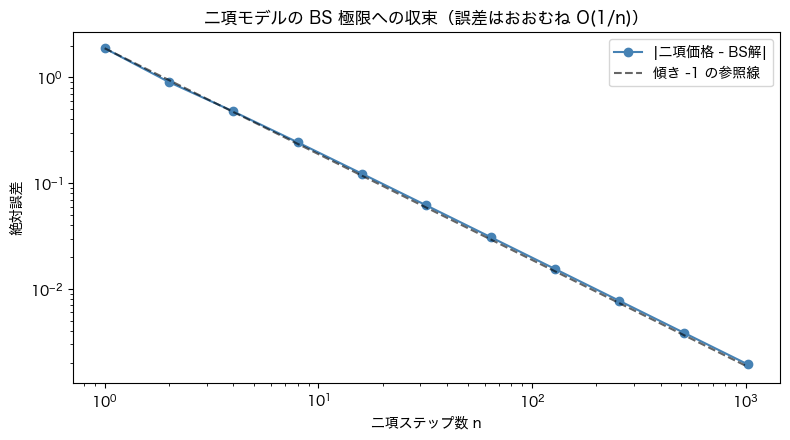

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(ns, errs, "o-", color="steelblue", label="|二項価格 - BS解|")
ax.loglog(ns, errs[0] * ns[0] / np.array(ns), "k--", alpha=0.6, label="傾き -1 の参照線")
ax.set_xlabel("二項ステップ数 n")
ax.set_ylabel("絶対誤差")
ax.set_title("二項モデルの BS 極限への収束（誤差はおおむね O(1/n)）")
ax.legend()
plt.tight_layout()
plt.show()

### 検証 2：複製コスト = リスク中立期待値（モンテカルロ）

リスク中立測度 $\mathbb{Q}$（ドリフト $r$）で株価を満期までシミュレーションし、割引ペイオフの
平均をとります。これが複製から出た BS 価格に一致すれば、「複製コスト = リスク中立期待値」を
数値で確かめたことになります。

In [9]:
n_mc = 200_000
_, W_mc = brownian_paths(n_mc, 1, T, seed=7)   # 満期だけ必要なので 1 ステップ
WT = W_mc[:, -1]
ST_Q = S0 * np.exp((r_cont - 0.5 * sigma ** 2) * T + sigma * WT)
payoff = np.maximum(ST_Q - K, 0.0)
mc_price = np.exp(-r_cont * T) * payoff.mean()
mc_se = np.exp(-r_cont * T) * payoff.std(ddof=1) / np.sqrt(n_mc)

print(f"複製（BS 解析解）価格   = {bs_ref:.6f}")
print(f"リスク中立 MC 価格      = {mc_price:.6f} ± {1.96*mc_se:.6f}（95%）")
print(f"差                      = {mc_price - bs_ref:+.6f}")
assert abs(mc_price - bs_ref) < 5 * mc_se + 1e-3
print("→ 複製コストとリスク中立期待値が（MC 誤差の範囲で）一致しました")

複製（BS 解析解）価格   = 9.413403
リスク中立 MC 価格      = 9.410063 ± 0.061814（95%）
差                      = -0.003340
→ 複製コストとリスク中立期待値が（MC 誤差の範囲で）一致しました


### QuantLib による独立ベンチマーク

最後に QuantLib の解析ヨーロピアン・エンジンと二項エンジンで、自作価格を突き合わせます。

In [10]:
import QuantLib as ql

print("QuantLib version:", ql.__version__)

today = ql.Date(15, 5, 2026)
ql.Settings.instance().evaluationDate = today
day_count = ql.Actual365Fixed()
maturity = today + ql.Period(365, ql.Days)

spot = ql.QuoteHandle(ql.SimpleQuote(S0))
flat_r = ql.YieldTermStructureHandle(
    ql.FlatForward(today, r_cont, day_count))
flat_q = ql.YieldTermStructureHandle(
    ql.FlatForward(today, 0.0, day_count))
flat_vol = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(today, ql.NullCalendar(), sigma, day_count))
process = ql.BlackScholesMertonProcess(spot, flat_q, flat_r, flat_vol)

payoff_ql = ql.PlainVanillaPayoff(ql.Option.Call, K)
exercise = ql.EuropeanExercise(maturity)
option = ql.VanillaOption(payoff_ql, exercise)

option.setPricingEngine(ql.AnalyticEuropeanEngine(process))
ql_analytic = option.NPV()

option.setPricingEngine(ql.BinomialVanillaEngine(process, "crr", 1024))
ql_binomial = option.NPV()

print(f"自作 BS 解析解           = {bs_ref:.6f}")
print(f"QuantLib 解析エンジン    = {ql_analytic:.6f}")
print(f"QuantLib 二項(CRR,1024)  = {ql_binomial:.6f}")
print(f"自作二項(CRR,1024)       = {binomial_price(S0, K, r_cont, sigma, T, 1024):.6f}")
# QuantLib は Actual365 で満期が 365/365=1 年ちょうどなので厳密一致に近い
assert abs(ql_analytic - bs_ref) < 1e-3
print("→ 自作実装と QuantLib が一致（実装の正しさを確認）")

QuantLib version: 1.42.1
自作 BS 解析解           = 9.413403
QuantLib 解析エンジン    = 9.413403
QuantLib 二項(CRR,1024)  = 9.411448
自作二項(CRR,1024)       = 9.411467
→ 自作実装と QuantLib が一致（実装の正しさを確認）


## 実データ適用

実データは合成データ（seed 固定）で代用します。ここでの主題は「**実測度のドリフト $\mu$ を
どう変えても、オプション価格は変わらない**」ことを数値で示し、そこから「ではなぜ実務で
ドリフトを推定するのか」に答えることです。

### 実測度シミュレーション + Girsanov による測度変換

実測度 $\mathbb{P}$（ドリフト $\mu$）で株価をシミュレーションし、ラドン・ニコディム微分
$L = \dfrac{d\mathbb{Q}}{d\mathbb{P}} = \exp(-\theta W_T - \tfrac12\theta^2 T)$、$\theta=(\mu-r)/\sigma$ で
重み付けすると、$\mathbb{Q}$ 期待値が得られます。

$$
f_0 = \mathbb{E}^{\mathbb{Q}}\big[e^{-rT}\,\text{payoff}\big]
    = \mathbb{E}^{\mathbb{P}}\big[L\,e^{-rT}\,\text{payoff}\big].
$$

右辺は $\mathbb{P}$ 上の期待値です。$\mu$ を変えると経路 $S_T^{\mathbb{P}}$ も重み $L$ も変わりますが、
積は $\mu$ に依存しません。異なる $\mu$ で全て同じ価格になることを確認します。

In [11]:
mus = [-0.05, 0.00, 0.05, 0.12, 0.25]
n_mc = 200_000
_, W_mc = brownian_paths(n_mc, 1, T, seed=2024)
WT = W_mc[:, -1]

print(f"共通の無リスク金利 r = {r_cont}, ボラ sigma = {sigma}")
print(f"複製（BS 解析解）価格 = {bs_ref:.6f}\n")
print(f"{'実測度 mu':>10} {'θ=(μ-r)/σ':>12} {'RN重み付け Q価格':>18} {'BSとの差':>12}")
for mu_i in mus:
    theta = (mu_i - r_cont) / sigma
    ST_P = S0 * np.exp((mu_i - 0.5 * sigma ** 2) * T + sigma * WT)   # P で生成
    L = np.exp(-theta * WT - 0.5 * theta ** 2 * T)                  # dQ/dP
    payoff = np.maximum(ST_P - K, 0.0)
    price_i = np.exp(-r_cont * T) * (L * payoff).mean()
    print(f"{mu_i:10.2f} {theta:12.4f} {price_i:18.6f} {price_i - bs_ref:+12.6f}")

print("\n→ 実測度ドリフト μ を -5% から +25% まで動かしても価格は不変（θ が付け替えを吸収）")

共通の無リスク金利 r = 0.03, ボラ sigma = 0.2
複製（BS 解析解）価格 = 9.413403

    実測度 mu    θ=(μ-r)/σ         RN重み付け Q価格        BSとの差
     -0.05      -0.4000           9.397236    -0.016167
      0.00      -0.1500           9.404423    -0.008980
      0.05       0.1000           9.407802    -0.005601
      0.12       0.4500           9.414436    +0.001033
      0.25       1.1000           9.421560    +0.008156

→ 実測度ドリフト μ を -5% から +25% まで動かしても価格は不変（θ が付け替えを吸収）


### では、なぜ実務でドリフトを推定するのか

価格に $\mu$ が効かないのは、価格が「無裁定の複製コスト」だからです。複製で市場リスクを
消してしまうので、現実の期待リターンは価格に残りません。にもかかわらず実務で $\mu$（実測度の
ドリフト）を推定するのは、**価格づけとは別の目的**があるからです。

| 目的 | 使う測度 | ドリフト $\mu$ の役割 |
|---|---|---|
| デリバティブ価格づけ | リスク中立 $\mathbb{Q}$ | 使わない（$r$ に置き換わる） |
| リスク管理・VaR / ES | 実測度 $\mathbb{P}$ | 将来分布の中心を決める（S3-5） |
| ストレステスト・シナリオ生成 | 実測度 $\mathbb{P}$ | 「現実に起きうる」経路の生成 |
| 期待収益・資産配分 | 実測度 $\mathbb{P}$ | 期待リターンそのもの |
| リスクの市場価格の推定 | $\mathbb{P}$ と $\mathbb{Q}$ の橋渡し | $\theta=(\mu-r)/\sigma$ を通じてプレミアムを測る |

つまり「価格を出すだけ」なら $\mu$ は不要ですが、「その価格の周りで自分がどれだけ損を
しうるか」「どれだけ儲かると期待できるか」を語る瞬間に、実測度のドリフトが必要になります。
価格づけ（$\mathbb{Q}$）とリスク管理（$\mathbb{P}$）で使う測度が違う、というのが実務の要点です。

## 演習

1. **二項モデルの BS 極限への収束**
   プット・オプション（$S_0=100$, $K=100$, $r=3\%$, $\sigma=25\%$, $T=1$）について、
   ステップ数 $n\in\{1,2,4,\dots,2048\}$ で二項価格を計算し、Black–Scholes 解析解との
   絶対誤差を両対数でプロットせよ。誤差がおおむね $O(1/n)$ で減ることを確認し、
   奇数・偶数ステップで誤差が振動する様子にも触れよ。

2. **Girsanov による測度変換とマルチンゲール性**
   実測度ドリフト $\mu=0.15$、$r=3\%$、$\sigma=20\%$ の幾何ブラウン運動を
   `bondlab.sim.brownian_paths` で生成せよ。ラドン・ニコディム微分
   $L=\exp(-\theta W_T-\tfrac12\theta^2 T)$ で重み付けし、$\mathbb{Q}$ の下で割引株価
   $e^{-rT}S_T$ の期待値が $S_0$（マルチンゲール）になることを数値で確認せよ。あわせて
   重みなし（実測度のまま）だと期待値が $S_0 e^{(\mu-r)T}$ にずれることも示せ。

解答例は `solutions/S4/sol_0405.py` に置きます。

## 用語集

定義の正は `glossary/04_stochastic.md`。ここでは初出語の一行要約のみ示します。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| リスク中立測度 | risk-neutral measure | 割引資産をマルチンゲールにする確率測度。価格づけに使う |
| ニュメレール | numéraire | 価値を測る基準に選ぶ正価格資産。取り替えると測度が変わる |
| Girsanov の定理 | Girsanov's theorem | 測度変換でブラウン運動のドリフトが付け替わることを述べる定理 |
| 複製ポートフォリオ | replicating portfolio | デリバティブと同じペイオフを再現する原資産・債の組み合わせ |
| リスクの市場価格 | market price of risk | $\theta=(\mu-r)/\sigma$。リスク1単位あたりの超過リターン |